# MNIST Denoising Autoencoder
- Build a deep learning model that can remove noise from images using an autoencoder on MNIST
- Three Autoencoder were used for this model.

| S.No. | Model | Decoder Type |
|---|-------|-------------|
| 1 | **FFNN Autoencoder** | Fully-connected (Linear) layers |
| 2 | **Transpose-Conv Autoencoder** | ConvTranspose2d upsampling |
| 3 | **Upsample-Conv Autoencoder** | Bilinear upsample + Conv2d (no checkerboard) |


**PNG Dataset:** [MNIST on Kaggle](https://www.kaggle.com/datasets/awsaf49/mnist-dataset)  
**Compressed dataset and Reference:** [NvsYashwanth/MNIST-Autoecncoder](https://github.com/NvsYashwanth/MNIST-Autoecncoder)

## 1. Install & Import Dependencies

In [ ]:
import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split

import torchvision
from torchvision import transforms, datasets
from sklearn.decomposition import PCA

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {device}')
print(f'PyTorch: {torch.__version__}')

Device : cuda
PyTorch: 2.12.0+cu126


## 2. Data Preparation

### 2.1 Load MNIST
Dataset was loaded from github rep which was compressed.

This cell also contains commented out code for PNG dataset.
- `training/<digit>/*.png` — 60,000 training images, organised by digit class (0-9)
- `testing/<digit>/*.png` — 10,000 test images, organised by digit class (0-9)

All pixel values are normalised to **[0, 1]** (divide by 255).

In [ ]:
"""# Load MNIST from mnist_png folder (training/<digit>/*.png, testing/<digit>/*.png) ──
from PIL import Image
from glob import glob

MNIST_PNG_DIR = './data/mnist_png'   # ← folder containing 'training/' and 'testing/' subfolders

def load_mnist_png(split_dir):
    images, labels = [], []
    for digit in range(10):
        for fp in sorted(glob(os.path.join(split_dir, str(digit), '*.png'))):
            img = Image.open(fp).convert('L')
            images.append(np.array(img, dtype=np.float32) / 255.0)
            labels.append(digit)
    images = np.stack(images).reshape(-1, 1, 28, 28)
    labels = np.array(labels, dtype=np.int64)
    return images, labels

print('Loading mnist_png dataset ...')
train_pixels, train_labels = load_mnist_png(os.path.join(MNIST_PNG_DIR, 'training'))
test_pixels,  test_labels  = load_mnist_png(os.path.join(MNIST_PNG_DIR, 'testing'))
print(f'Loaded mnist_png  |  Train: {len(train_pixels):,}  |  Test: {len(test_pixels):,}')
"""

# Load MNIST via torchvision (uses local ./data/MNIST/raw if present, else downloads) ──
raw_train = datasets.MNIST('./data', train=True,  download=True, transform=transforms.ToTensor())
raw_test  = datasets.MNIST('./data', train=False, download=True, transform=transforms.ToTensor())

train_pixels = raw_train.data.numpy().reshape(-1, 1, 28, 28).astype(np.float32) / 255.0
train_labels = raw_train.targets.numpy()
test_pixels  = raw_test.data.numpy().reshape(-1, 1, 28, 28).astype(np.float32)  / 255.0
test_labels  = raw_test.targets.numpy()

print(f'MNIST loaded  |  Train: {len(train_pixels):,}  |  Test: {len(test_pixels):,}')

# Dataset statistics
print(f'\nPixel range : [{train_pixels.min():.2f}, {train_pixels.max():.2f}]')
print(f'Image shape : {train_pixels.shape[1:]}')
print(f'Classes     : {np.unique(train_labels)}')

MNIST loaded  |  Train: 60,000  |  Test: 10,000

Pixel range : [0.00, 1.00]
Image shape : (1, 28, 28)
Classes     : [0 1 2 3 4 5 6 7 8 9]


### 2.2 Exploratory Data Analysis

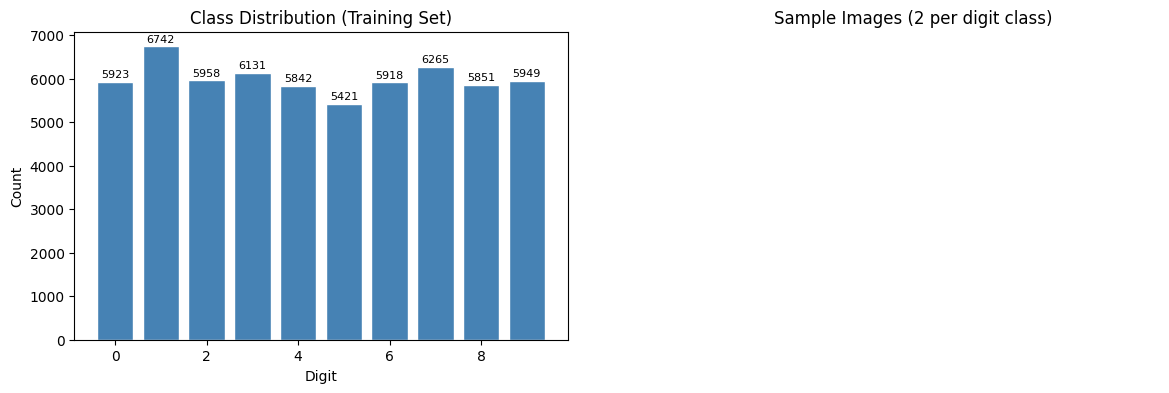

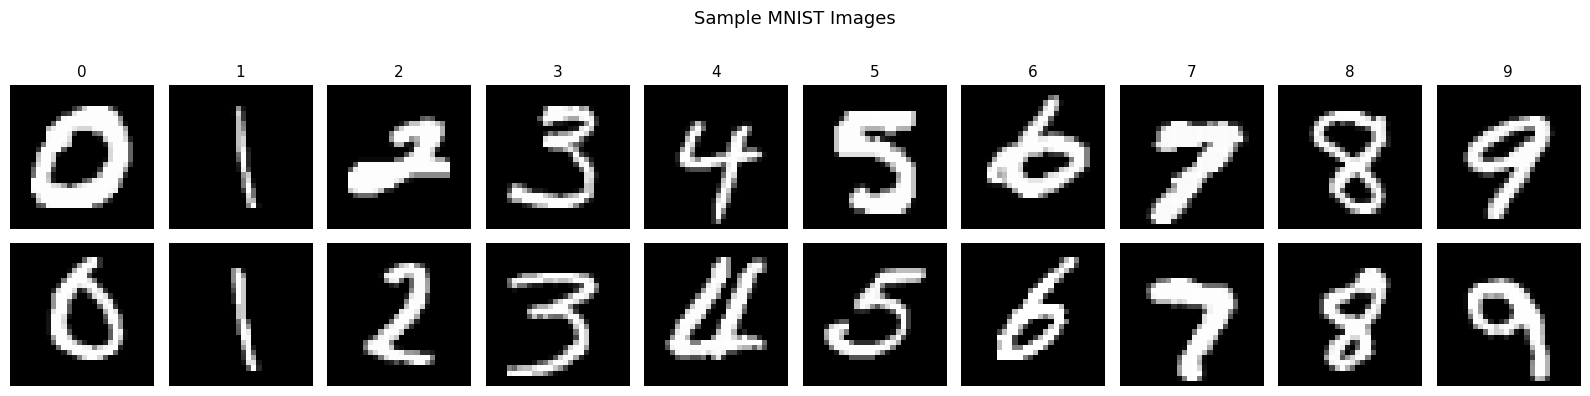

In [50]:
# Class distribution
unique, counts = np.unique(train_labels, return_counts=True)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].bar(unique, counts, color='steelblue', edgecolor='white')
axes[0].set_title('Class Distribution (Training Set)', fontsize=12)
axes[0].set_xlabel('Digit'); axes[0].set_ylabel('Count')
for x, y in zip(unique, counts):
    axes[0].text(x, y + 100, str(y), ha='center', fontsize=8)

# Sample images grid
axes[1].axis('off')
axes[1].set_title('Sample Images (2 per digit class)', fontsize=12)

fig2, ax2 = plt.subplots(2, 10, figsize=(16, 4))
fig2.suptitle('Sample MNIST Images', fontsize=13, y=1.02)
for digit in range(10):
    idxs = np.where(train_labels == digit)[0]
    for row, idx in enumerate(np.random.choice(idxs, 2, replace=False)):
        ax2[row, digit].imshow(train_pixels[idx, 0], cmap='gray')
        ax2[row, digit].axis('off')
        if row == 0:
            ax2[row, digit].set_title(str(digit), fontsize=11)

plt.tight_layout()
plt.show()

### 2.3 Noise Generation

Gaussian noise is added with a configurable noise_factor σ.  
The corrupted values are clamped to [0, 1] to stay in valid pixel range.

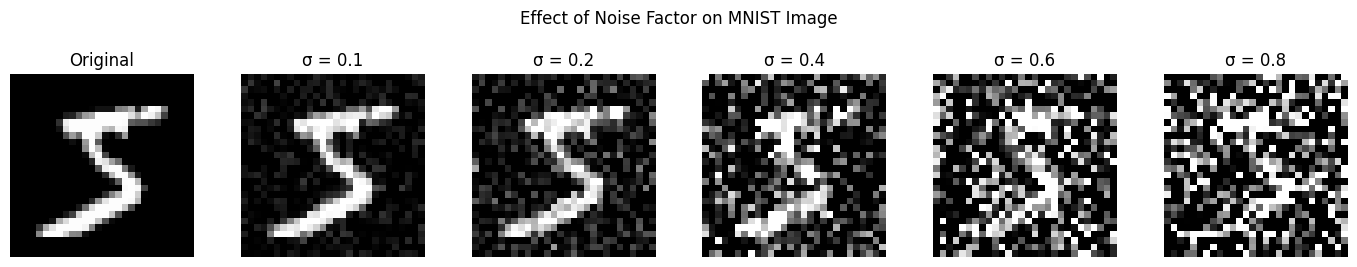

In [51]:
def add_gaussian_noise(images, noise_factor=0.4):
    """Add Gaussian noise ~ N(0, noise_factor) and clamp to [0,1]."""
    noise = noise_factor * np.random.randn(*images.shape).astype(np.float32)
    return np.clip(images + noise, 0.0, 1.0)


# Visualise effect of different noise levels
noise_levels = [0.1, 0.2, 0.4, 0.6, 0.8]
sample_img   = train_pixels[0, 0]

fig, axes = plt.subplots(1, len(noise_levels) + 1, figsize=(14, 2.5))
axes[0].imshow(sample_img, cmap='gray'); axes[0].set_title('Original'); axes[0].axis('off')
for ax, nf in zip(axes[1:], noise_levels):
    noisy = np.clip(sample_img + nf * np.random.randn(*sample_img.shape).astype(np.float32), 0, 1)
    ax.imshow(noisy, cmap='gray')
    ax.set_title(f'σ = {nf}')
    ax.axis('off')
plt.suptitle('Effect of Noise Factor on MNIST Image', fontsize=12, y=1.05)
plt.tight_layout(); plt.show()

### 2.4 Dataset & DataLoaders

Train : 48,000 samples  (375 batches)
Val   : 12,000 samples  (94 batches)
Test  : 10,000 samples  (79 batches)


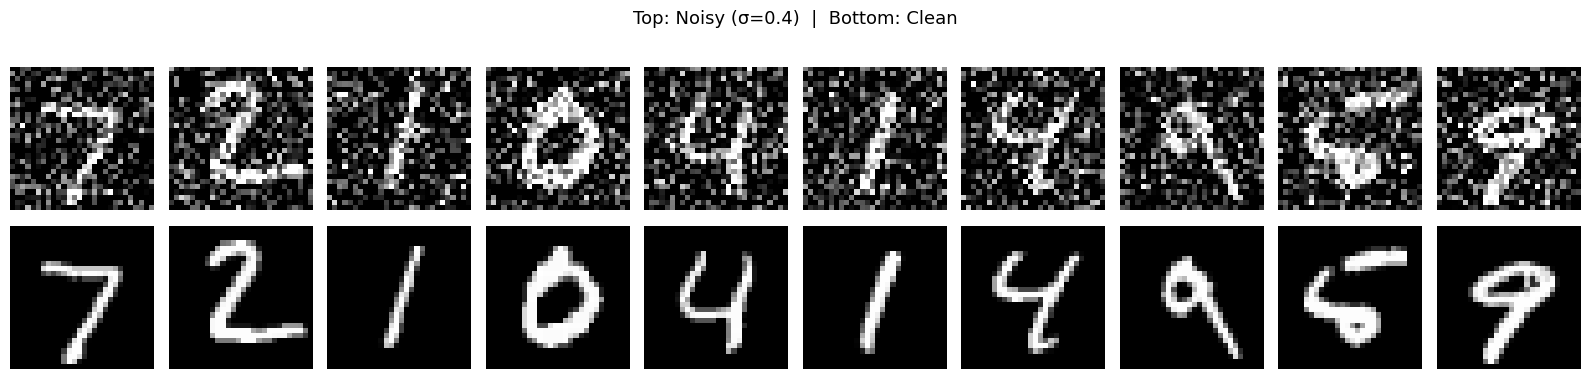

In [52]:
class MNISTDenoisingDataset(Dataset):
    """Returns (noisy_image, clean_image, label) triples."""

    def __init__(self, images, labels, noise_factor=0.4):
        self.clean  = torch.tensor(images)
        self.noisy  = torch.tensor(add_gaussian_noise(images, noise_factor))
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):  return len(self.clean)

    def __getitem__(self, idx):
        return self.noisy[idx], self.clean[idx], self.labels[idx]


# Hyperparameters
NOISE_FACTOR = 0.4
BATCH_SIZE   = 128
VAL_FRAC     = 0.20

n_val   = int(len(train_pixels) * VAL_FRAC)
n_train = len(train_pixels) - n_val

full_ds  = MNISTDenoisingDataset(train_pixels, train_labels, NOISE_FACTOR)
train_ds, val_ds = random_split(full_ds, [n_train, n_val],
                                generator=torch.Generator().manual_seed(SEED))
test_ds  = MNISTDenoisingDataset(test_pixels, test_labels, NOISE_FACTOR)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f'Train : {n_train:,} samples  ({len(train_loader)} batches)')
print(f'Val   : {n_val:,} samples  ({len(val_loader)} batches)')
print(f'Test  : {len(test_ds):,} samples  ({len(test_loader)} batches)')

# Quick sanity check
noisy_b, clean_b, _ = next(iter(test_loader))
fig, axes = plt.subplots(2, 10, figsize=(16, 4))
fig.suptitle('Top: Noisy (σ=0.4)  |  Bottom: Clean', fontsize=13)
for i in range(10):
    axes[0, i].imshow(noisy_b[i, 0].numpy(), cmap='gray', vmin=0, vmax=1); axes[0, i].axis('off')
    axes[1, i].imshow(clean_b[i, 0].numpy(), cmap='gray', vmin=0, vmax=1); axes[1, i].axis('off')
plt.tight_layout(); plt.show()

## 3. Model Architectures

All three autoencoders share the same **training target**: given a noisy image **x̃**, output a reconstruction **x̂** close to the clean image **x**.

The loss function is **MSE**: L = (1/n) Σ (x̂ᵢ - xᵢ)²

Comparing pixel intensities is inherently a regression task , MSE penalises large deviations strongly and is differentiable everywhere, making it the standard choice for reconstruction autoencoders.

### 3.1 Model 1 — FFNN Autoencoder

Flattens each 28×28 image to a 784-vector, encodes to 64 dims, then decodes back.

In [53]:
class FFNNAutoencoder(nn.Module):
    """
    Fully-connected (dense) autoencoder.
    Encoder : 784 → 512 → 256 → 128 → 64
    Decoder : 64  → 128 → 256 → 512 → 784
    """
    def __init__(self, encoding_dim=64):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(784, 512), nn.ReLU(True), nn.BatchNorm1d(512), nn.Dropout(0.2),
            nn.Linear(512, 256), nn.ReLU(True), nn.BatchNorm1d(256),
            nn.Linear(256, 128), nn.ReLU(True),
            nn.Linear(128, encoding_dim), nn.ReLU(True),
        )
        self.decoder = nn.Sequential(
            nn.Linear(encoding_dim, 128), nn.ReLU(True),
            nn.Linear(128, 256), nn.ReLU(True), nn.BatchNorm1d(256),
            nn.Linear(256, 512), nn.ReLU(True), nn.BatchNorm1d(512),
            nn.Linear(512, 784), nn.Sigmoid(),
        )
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                std = 1.0 / math.sqrt(m.weight.size(1))
                nn.init.normal_(m.weight, 0, std)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        b = x.size(0)
        z   = self.encoder(x.view(b, -1))
        out = self.decoder(z)
        return out.view(b, 1, 28, 28)


ffnn_model = FFNNAutoencoder(encoding_dim=64).to(device)
n = sum(p.numel() for p in ffnn_model.parameters() if p.requires_grad)
print(f'FFNN Autoencoder  |  Trainable params: {n:,}')
print(ffnn_model)

FFNN Autoencoder  |  Trainable params: 1,152,592
FFNNAutoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU(inplace=True)
    (2): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): ReLU(inplace=True)
    (6): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (7): Linear(in_features=256, out_features=128, bias=True)
    (8): ReLU(inplace=True)
    (9): Linear(in_features=128, out_features=64, bias=True)
    (10): ReLU(inplace=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=64, out_features=128, bias=True)
    (1): ReLU(inplace=True)
    (2): Linear(in_features=128, out_features=256, bias=True)
    (3): ReLU(inplace=True)
    (4): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)

### 3.2 Model 2 — Transpose-Conv CNN Autoencoder

Spatially aware encoder via strided convolutions; decoder uses ConvTranspose2d for learnable upsampling.

In [54]:
class TransConvAutoencoder(nn.Module):
    """
    Encoder : 1×28×28 → 16×14×14 → 4×7×7   (bottleneck = 196 values)
    Decoder : 4×7×7  → 16×14×14 → 1×28×28  (ConvTranspose2d)
    """
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1,  16, 3, stride=2, padding=1), nn.ReLU(True), nn.BatchNorm2d(16),
            nn.Conv2d(16,  4, 3, stride=2, padding=1), nn.ReLU(True),
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(4, 16, 2, stride=2), nn.ReLU(True), nn.BatchNorm2d(16),
            nn.ConvTranspose2d(16, 1, 2, stride=2), nn.Sigmoid(),
        )

    def forward(self, x): return self.decoder(self.encoder(x))


tconv_model = TransConvAutoencoder().to(device)
n = sum(p.numel() for p in tconv_model.parameters() if p.requires_grad)
print(f'Transpose-Conv Autoencoder  |  Trainable params: {n:,}')
print(tconv_model)

Transpose-Conv Autoencoder  |  Trainable params: 1,141
TransConvAutoencoder(
  (encoder): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (3): Conv2d(16, 4, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (4): ReLU(inplace=True)
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(4, 16, kernel_size=(2, 2), stride=(2, 2))
    (1): ReLU(inplace=True)
    (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (3): ConvTranspose2d(16, 1, kernel_size=(2, 2), stride=(2, 2))
    (4): Sigmoid()
  )
)


### 3.3 Model 3 - Upsample-Conv CNN Autoencoder

Replaces ConvTranspose2d with bilinear upsampling + regular Conv2d to avoid checkerboard artifacts.

In [55]:
class UpsampleAutoencoder(nn.Module):
    """
    Encoder : 1×28×28 → 16×14×14 → 8×7×7 → 4×7×7
    Decoder : 4×7×7  → Upsample → 8×14×14 → Upsample → 16×28×28 → 1×28×28
    """
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1,  16, 3, stride=2, padding=1), nn.ReLU(True), nn.BatchNorm2d(16),
            nn.Conv2d(16,  8, 3, stride=2, padding=1), nn.ReLU(True), nn.BatchNorm2d(8),
            nn.Conv2d(8,   4, 3, stride=1, padding=1), nn.ReLU(True),
        )
        self.decoder = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(4,   8, 3, padding=1), nn.ReLU(True), nn.BatchNorm2d(8),
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(8,  16, 3, padding=1), nn.ReLU(True), nn.BatchNorm2d(16),
            nn.Conv2d(16,  1, 3, padding=1), nn.Sigmoid(),
        )

    def forward(self, x): return self.decoder(self.encoder(x))


upsamp_model = UpsampleAutoencoder().to(device)
n = sum(p.numel() for p in upsamp_model.parameters() if p.requires_grad)
print(f'Upsample-Conv Autoencoder  |  Trainable params: {n:,}')
print(upsamp_model)

Upsample-Conv Autoencoder  |  Trainable params: 3,317
UpsampleAutoencoder(
  (encoder): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (3): Conv2d(16, 8, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (4): ReLU(inplace=True)
    (5): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): Conv2d(8, 4, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
  )
  (decoder): Sequential(
    (0): Upsample(scale_factor=2.0, mode='bilinear')
    (1): Conv2d(4, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (2): ReLU(inplace=True)
    (3): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (4): Upsample(scale_factor=2.0, mode='bilinear')
    (5): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), pad

## 4. Training Setup

### Design Choices
| Component | Choice | Reason |
|-----------|--------|--------|
| **Loss** | nn.MSELoss | Pixel-wise regression; penalises large errors quadratically |
| **Optimizer** | Adam (lr=1e-3, wd=1e-5) | Adaptive LR; weight decay prevents overfitting |
| **Scheduler** | ReduceLROnPlateau (patience=3) | Halves LR when val loss plateaus |


In [68]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total = 0.0
    for noisy, clean, _ in loader:
        noisy, clean = noisy.to(device), clean.to(device)
        optimizer.zero_grad()
        loss = criterion(model(noisy), clean)
        loss.backward()
        optimizer.step()
        total += loss.item() * noisy.size(0)
    return total / len(loader.dataset)


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total = 0.0
    for noisy, clean, _ in loader:
        noisy, clean = noisy.to(device), clean.to(device)
        total += criterion(model(noisy), clean).item() * noisy.size(0)
    return total / len(loader.dataset)


def train_model(model, train_loader, val_loader, epochs=20, lr=1e-3, name='Model'):
    """Full training loop: Adam + ReduceLROnPlateau + best-weight restore."""
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)

    history    = {'train_loss': [], 'val_loss': []}
    best_val   = float('inf')
    best_state = None
    
    print(f'  Training: {name}')

    for epoch in range(1, epochs + 1):
        tr = train_one_epoch(model, train_loader, criterion, optimizer)
        vl = evaluate(model, val_loader, criterion)
        scheduler.step(vl)
        history['train_loss'].append(tr)
        history['val_loss'].append(vl)

        if vl < best_val:
            best_val   = vl
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

        if epoch % 5 == 0 or epoch == 1:
            print(f'  Epoch [{epoch:>3}/{epochs}]  Train: {tr:.6f}  Val: {vl:.6f}  '
                  f'LR: {optimizer.param_groups[0]["lr"]:.2e}')

    model.load_state_dict(best_state)
    print(f'\n  Best val loss: {best_val:.6f}')
    return history


def plot_losses(histories, names):
    fig, axes = plt.subplots(1, len(histories), figsize=(6*len(histories), 4), sharey=True)
    if len(histories) == 1: axes = [axes]
    for ax, h, name in zip(axes, histories, names):
        ax.plot(h['train_loss'], lw=2, label='Train')
        ax.plot(h['val_loss'],   lw=2, linestyle='--', label='Val')
        ax.set_title(name, fontsize=12); ax.set_xlabel('Epoch'); ax.legend(); ax.grid(alpha=0.3)
    axes[0].set_ylabel('MSE Loss')
    plt.suptitle('Training & Validation Loss Curves', fontsize=14, y=1.02)
    plt.tight_layout(); plt.show()

print('Training utilities ready.')

Training utilities ready.


## 5. Train All Three Models

> Each model trains for 20 epochs. On CPU ≈ 5–10 min each; on GPU ≈ 1–2 min.
- I used CUDA with Nvidia GTX 1650Ti.

In [69]:
EPOCHS = 20

ffnn_history   = train_model(ffnn_model,   train_loader, val_loader, EPOCHS, name='FFNN Autoencoder')
tconv_history  = train_model(tconv_model,  train_loader, val_loader, EPOCHS, name='Transpose-Conv Autoencoder')
upsamp_history = train_model(upsamp_model, train_loader, val_loader, EPOCHS, name='Upsample-Conv Autoencoder')

  Training: FFNN Autoencoder
  Epoch [  1/20]  Train: 0.013410  Val: 0.013532  LR: 1.00e-03
  Epoch [  5/20]  Train: 0.013196  Val: 0.013190  LR: 1.00e-03
  Epoch [ 10/20]  Train: 0.013025  Val: 0.012871  LR: 1.00e-03
  Epoch [ 15/20]  Train: 0.012943  Val: 0.012908  LR: 1.00e-03
  Epoch [ 20/20]  Train: 0.012831  Val: 0.012705  LR: 1.00e-03

  Best val loss: 0.012444
  Training: Transpose-Conv Autoencoder
  Epoch [  1/20]  Train: 0.015441  Val: 0.015342  LR: 1.00e-03
  Epoch [  5/20]  Train: 0.015312  Val: 0.015292  LR: 1.00e-03
  Epoch [ 10/20]  Train: 0.015092  Val: 0.015003  LR: 1.00e-03
  Epoch [ 15/20]  Train: 0.014961  Val: 0.014875  LR: 1.00e-03
  Epoch [ 20/20]  Train: 0.014889  Val: 0.014837  LR: 1.00e-03

  Best val loss: 0.014823
  Training: Upsample-Conv Autoencoder
  Epoch [  1/20]  Train: 0.009667  Val: 0.009585  LR: 1.00e-03
  Epoch [  5/20]  Train: 0.009561  Val: 0.009570  LR: 1.00e-03
  Epoch [ 10/20]  Train: 0.009433  Val: 0.009520  LR: 1.00e-03
  Epoch [ 15/20]  Tra

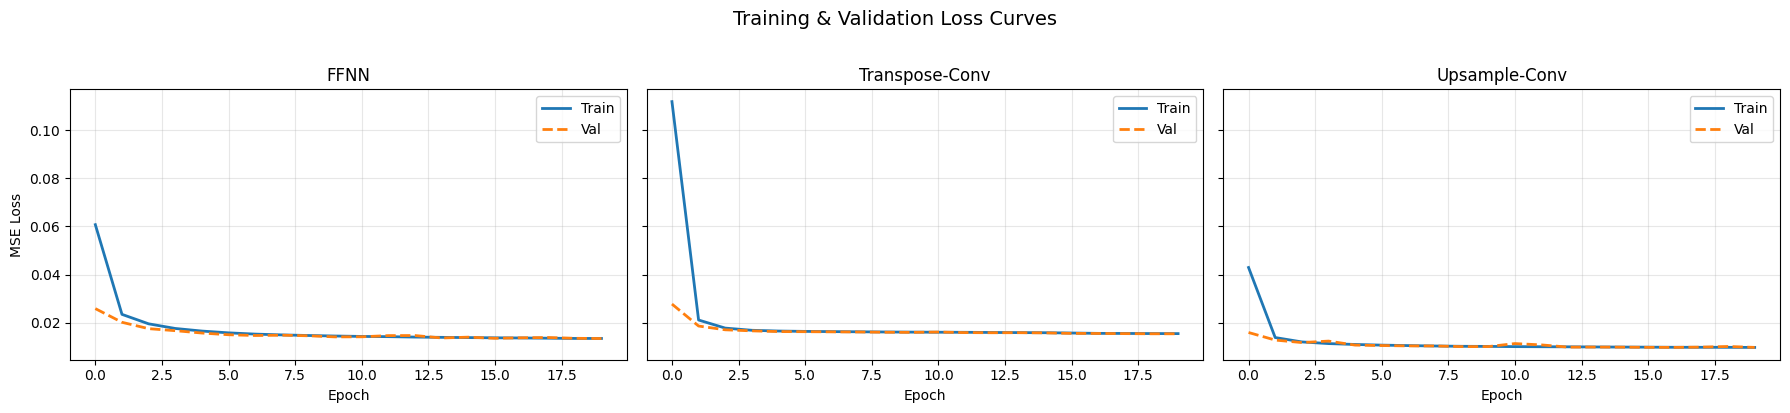

In [58]:
plot_losses(
    [ffnn_history, tconv_history, upsamp_history],
    ['FFNN', 'Transpose-Conv', 'Upsample-Conv']
)

## 6. Evaluation

### 6.1 Test MSE Loss

In [59]:
all_models = [ffnn_model, tconv_model, upsamp_model]
all_names  = ['FFNN', 'Transpose-Conv', 'Upsample-Conv']
criterion  = nn.MSELoss()

print(f'\n{"Model":<22}  {"Test MSE":>12}')
print('-' * 36)
test_losses = {}
for model, name in zip(all_models, all_names):
    loss = evaluate(model, test_loader, criterion)
    test_losses[name] = loss
    print(f'{name:<22}  {loss:>12.6f}')


Model                       Test MSE
------------------------------------
FFNN                        0.013182
Transpose-Conv              0.015196
Upsample-Conv               0.009577


### 6.2 PSNR & SSIM Metrics

- **PSNR** (Peak Signal-to-Noise Ratio): higher = better. dB scale. > 30 dB is generally good for images.
- **SSIM** (Structural Similarity Index): range [−1, 1], higher = better. Measures luminance, contrast, and structure.

In [60]:
def psnr(img1, img2, max_val=1.0):
    """Peak Signal-to-Noise Ratio (higher is better)."""
    mse = np.mean((img1 - img2) ** 2)
    return float('inf') if mse == 0 else 20 * np.log10(max_val / np.sqrt(mse))


def ssim_np(img1, img2, C1=0.01**2, C2=0.03**2):
    """Simplified SSIM for single-channel grayscale numpy arrays."""
    mu1, mu2 = img1.mean(), img2.mean()
    s12 = np.cov(img1.flatten(), img2.flatten())[0, 1]
    num   = (2*mu1*mu2 + C1) * (2*s12 + C2)
    denom = (mu1**2 + mu2**2 + C1) * (img1.var() + img2.var() + C2)
    return num / denom


@torch.no_grad()
def compute_metrics(model, loader, n_batches=8):
    model.eval()
    ps, ss = [], []
    for i, (noisy, clean, _) in enumerate(loader):
        if i >= n_batches: break
        recon = model(noisy.to(device)).cpu().numpy()
        clean = clean.numpy()
        for r, c in zip(recon, clean):
            ps.append(psnr(r[0], c[0]))
            ss.append(ssim_np(r[0], c[0]))
    return np.mean(ps), np.mean(ss)


print(f'\n{"Model":<22}  {"PSNR (dB)":>10}  {"SSIM":>8}')
print('-' * 44)
metrics = {}
for model, name in zip(all_models, all_names):
    p, s = compute_metrics(model, test_loader)
    metrics[name] = (p, s)
    print(f'{name:<22}  {p:>10.3f}  {s:>8.4f}')

# Baseline: noisy vs clean (no model)
ps, ss = [], []
for noisy, clean, _ in test_loader:
    for n_, c_ in zip(noisy.numpy(), clean.numpy()):
        ps.append(psnr(n_[0], c_[0]))
        ss.append(ssim_np(n_[0], c_[0]))
print(f'\n{"Noisy input (baseline)":<22}  {np.mean(ps):>10.3f}  {np.mean(ss):>8.4f}')


Model                    PSNR (dB)      SSIM
--------------------------------------------
FFNN                        19.158    0.9033
Transpose-Conv              18.334    0.8938
Upsample-Conv               20.595    0.9371

Noisy input (baseline)      11.001    0.5299


## 7. Result Visualisation

### 7.1 Side-by-Side: Noisy → All Models → Clean

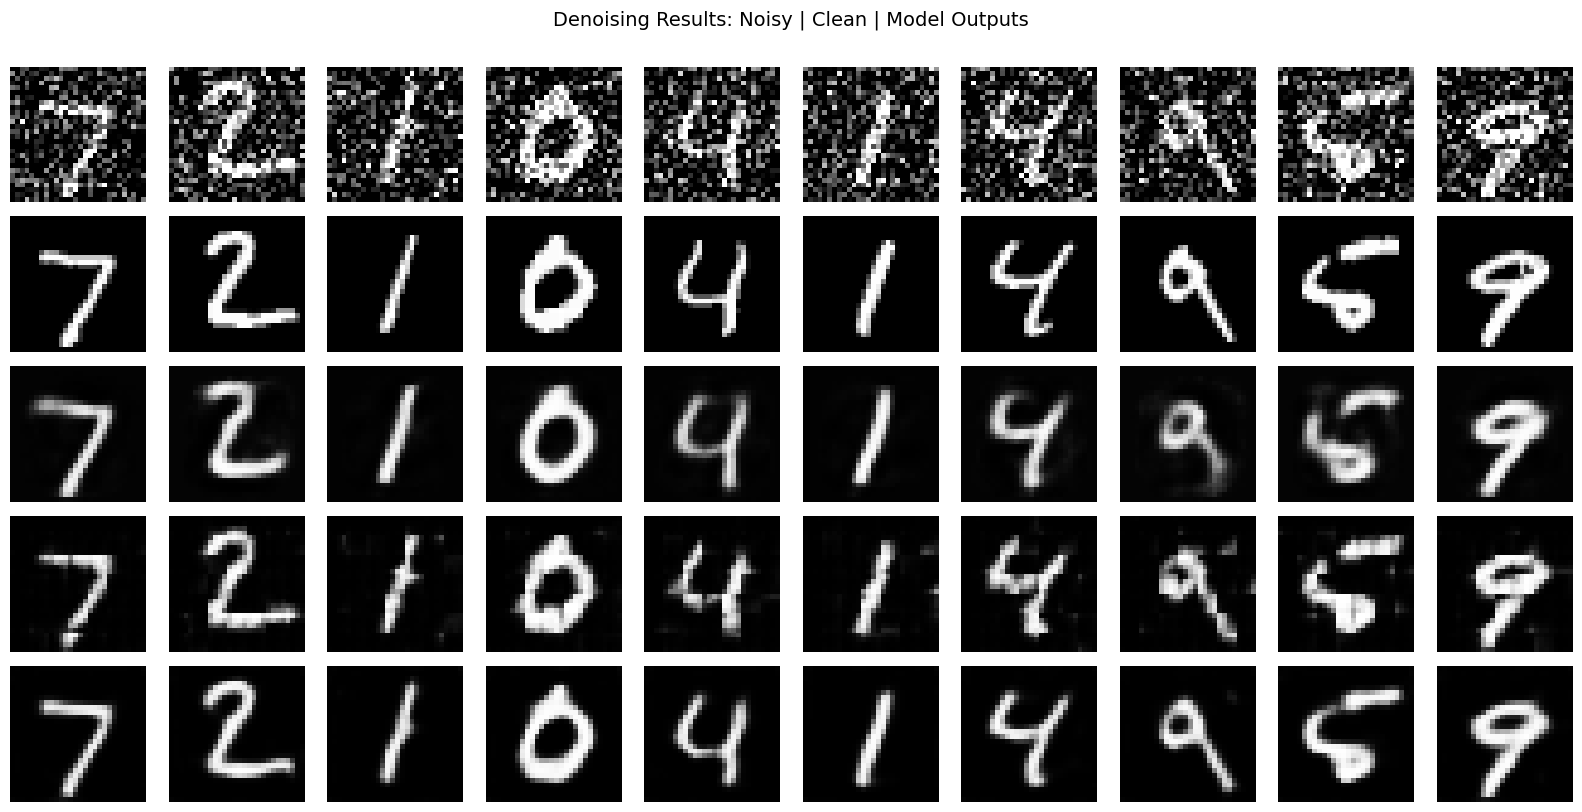

In [61]:
@torch.no_grad()
def get_batch(model, loader, n=10):
    model.eval()
    noisy, clean, _ = next(iter(loader))
    recon = model(noisy[:n].to(device)).cpu()
    return noisy[:n], recon, clean[:n]


def grid_compare(models, names, loader, n=10):
    """Grid: row0=Noisy, row1=Clean, rows 2..=each model."""
    n_rows = 2 + len(models)
    fig, axes = plt.subplots(n_rows, n, figsize=(n*1.6, n_rows*1.6))
    fig.suptitle('Denoising Results: Noisy | Clean | Model Outputs', fontsize=14, y=1.01)

    noisy_imgs, _, clean_imgs = get_batch(models[0], loader, n)
    row_labels = ['Noisy Input', 'Clean (GT)'] + names

    for col in range(n):
        axes[0, col].imshow(noisy_imgs[col, 0], cmap='gray', vmin=0, vmax=1)
        axes[0, col].axis('off')
        axes[1, col].imshow(clean_imgs[col, 0], cmap='gray', vmin=0, vmax=1)
        axes[1, col].axis('off')

    for r, (model, name) in enumerate(zip(models, names), start=2):
        _, recon, _ = get_batch(model, loader, n)
        for col in range(n):
            axes[r, col].imshow(recon[col, 0], cmap='gray', vmin=0, vmax=1)
            axes[r, col].axis('off')

    for r, label in enumerate(row_labels):
        axes[r, 0].set_ylabel(label, fontsize=9, rotation=90, labelpad=32)

    plt.tight_layout(); plt.show()


grid_compare(all_models, all_names, test_loader, n=10)

### 7.2 Residual Error Maps


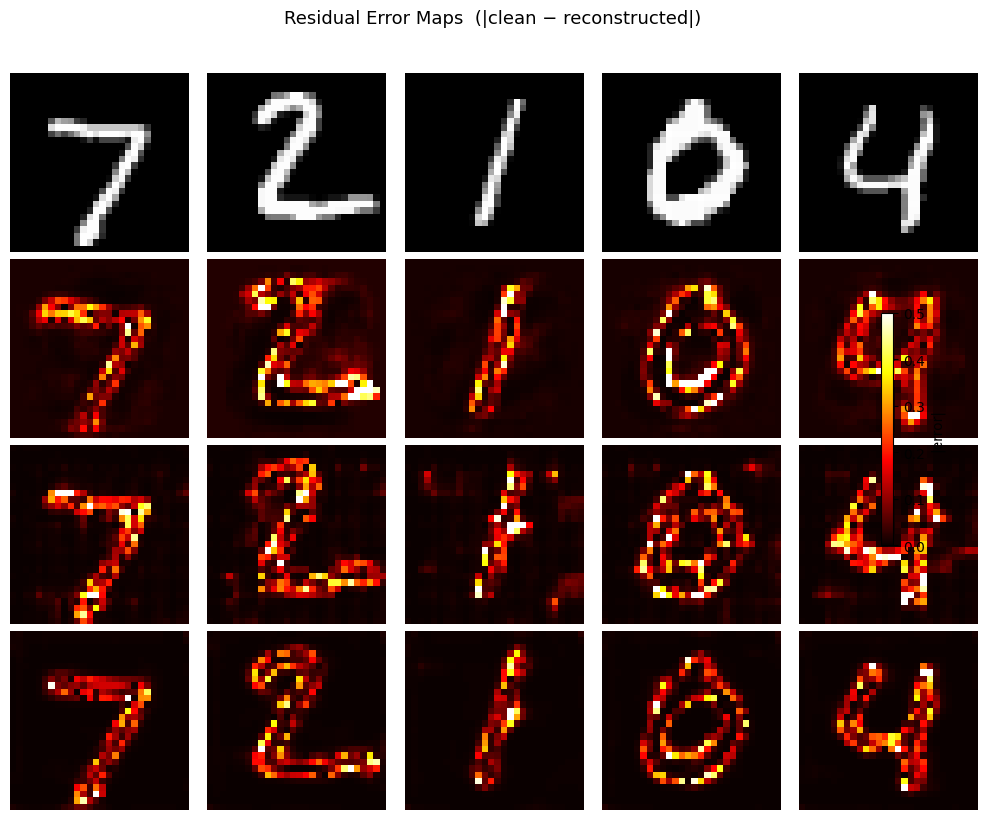

In [62]:
@torch.no_grad()
def residual_maps(models, names, loader, n=5):
    noisy, clean, _ = next(iter(loader))
    fig, axes = plt.subplots(len(models)+1, n, figsize=(n*2, (len(models)+1)*2))
    fig.suptitle('Residual Error Maps  (|clean − reconstructed|)', fontsize=13, y=1.02)

    axes[0, 0].set_ylabel('Clean GT', fontsize=9)
    for col in range(n):
        axes[0, col].imshow(clean[col, 0].numpy(), cmap='gray', vmin=0, vmax=1)
        axes[0, col].axis('off')

    for r, (model, name) in enumerate(zip(models, names), start=1):
        recon = model(noisy[:n].to(device)).cpu()
        err   = (clean[:n] - recon).abs()
        axes[r, 0].set_ylabel(name, fontsize=9)
        for col in range(n):
            im = axes[r, col].imshow(err[col, 0].numpy(), cmap='hot', vmin=0, vmax=0.5)
            axes[r, col].axis('off')

    plt.colorbar(im, ax=axes, fraction=0.015, pad=0.04, label='|error|')
    plt.tight_layout(); plt.show()

residual_maps(all_models, all_names, test_loader)

### 7.3 Single-Image Spotlight

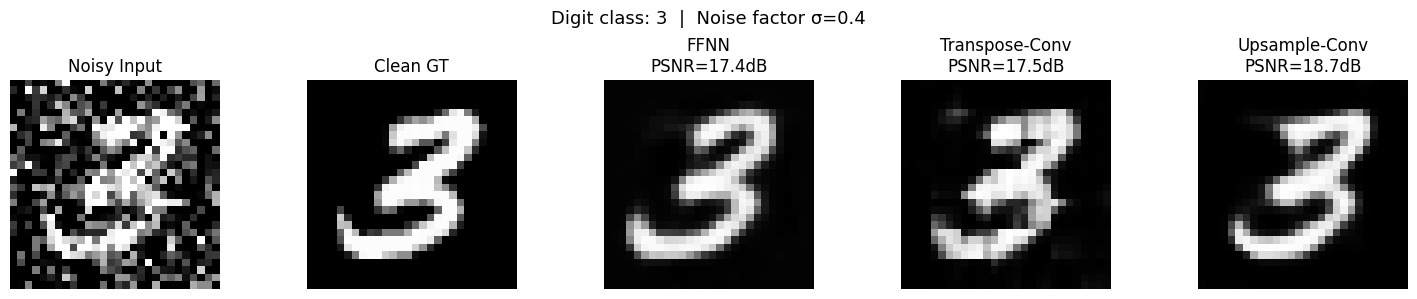

In [63]:
@torch.no_grad()
def single_spotlight(models, names, dataset, idx=None):
    """Detailed view of one image through all three models."""
    if idx is None: idx = np.random.randint(len(dataset))
    noisy, clean, label = dataset[idx]

    fig, axes = plt.subplots(1, 2 + len(models), figsize=(3*(2+len(models)), 3))
    fig.suptitle(f'Digit class: {label.item()}  |  Noise factor σ={NOISE_FACTOR}', fontsize=13)

    axes[0].imshow(noisy[0].numpy(), cmap='gray', vmin=0, vmax=1)
    axes[0].set_title('Noisy Input'); axes[0].axis('off')
    axes[1].imshow(clean[0].numpy(), cmap='gray', vmin=0, vmax=1)
    axes[1].set_title('Clean GT'); axes[1].axis('off')

    for ax, model, name in zip(axes[2:], models, names):
        recon = model(noisy.unsqueeze(0).to(device)).squeeze(0).cpu()
        p = psnr(recon[0].numpy(), clean[0].numpy())
        ax.imshow(recon[0].numpy(), cmap='gray', vmin=0, vmax=1)
        ax.set_title(f'{name}\nPSNR={p:.1f}dB'); ax.axis('off')

    plt.tight_layout(); plt.show()

single_spotlight(all_models, all_names, test_ds)

## 8. Latent Space Visualisation

The FFNN encoder produces a 64-D embedding. We reduce to 2D with PCA — digit clusters forming naturally confirms the model has learned meaningful representations.

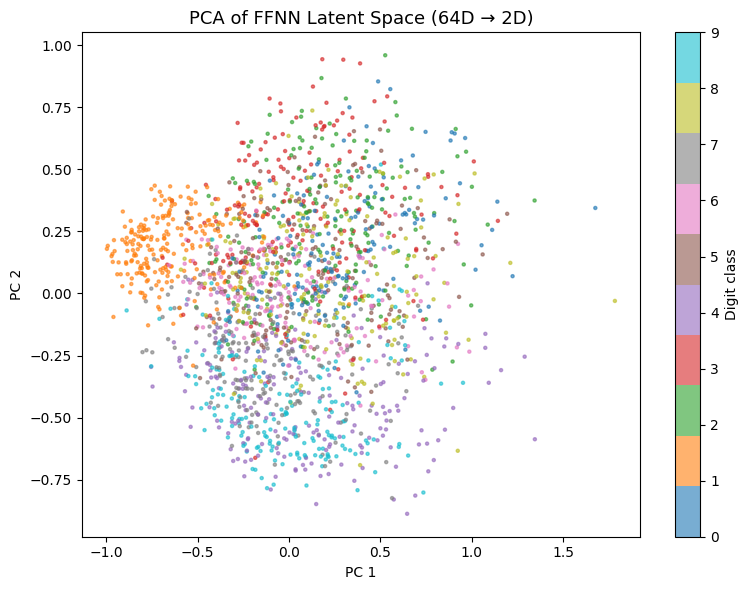

In [64]:
@torch.no_grad()
def extract_latents(model, loader, n_batches=15):
    model.eval()
    Z, Y = [], []
    for i, (noisy, _, labels) in enumerate(loader):
        if i >= n_batches: break
        x = noisy.to(device).view(noisy.size(0), -1)
        Z.append(model.encoder(x).cpu().numpy())
        Y.append(labels.numpy())
    return np.vstack(Z), np.concatenate(Y)

Z, Y = extract_latents(ffnn_model, test_loader)
Z2   = PCA(n_components=2, random_state=SEED).fit_transform(Z)

fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(Z2[:, 0], Z2[:, 1], c=Y, cmap='tab10', s=5, alpha=0.6)
plt.colorbar(sc, ax=ax, label='Digit class')
ax.set_title('PCA of FFNN Latent Space (64D → 2D)', fontsize=13)
ax.set_xlabel('PC 1'); ax.set_ylabel('PC 2')
plt.tight_layout(); plt.show()

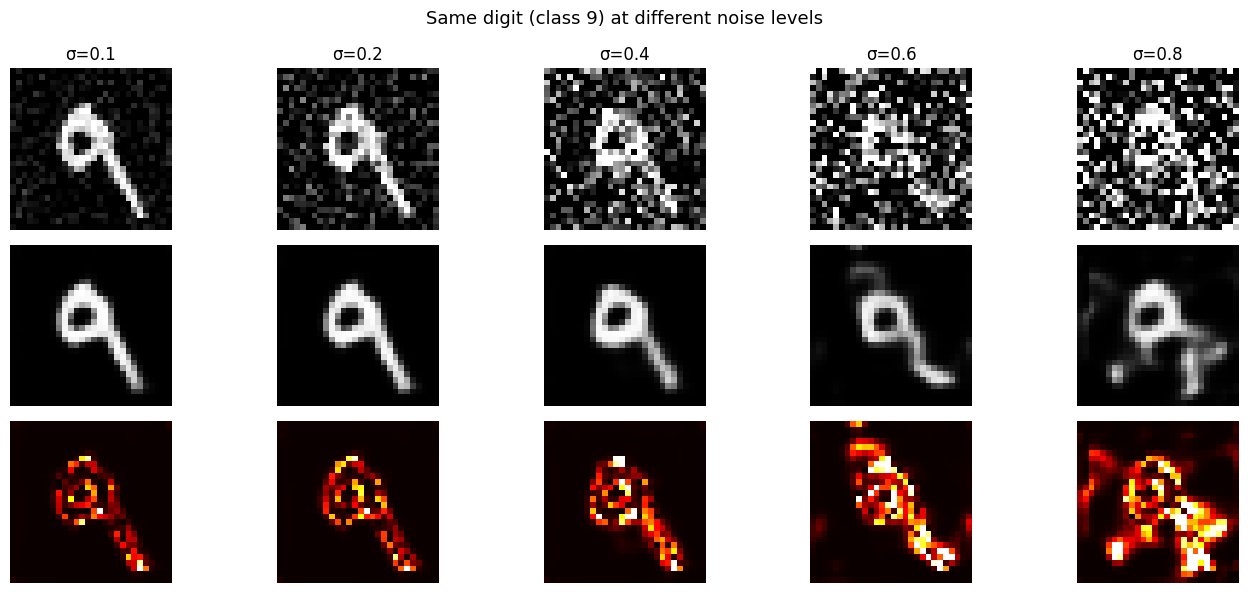

In [65]:
# Visual comparison across noise levels for the same digit
sample_img    = test_pixels[7:8]
sample_label_ = test_labels[7]

fig, axes = plt.subplots(3, len(noise_levels_exp), figsize=(14, 6))
fig.suptitle(f'Same digit (class {sample_label_}) at different noise levels', fontsize=13)

col_titles = [f'σ={nf}' for nf in noise_levels_exp]
row_titles = ['Noisy', 'Denoised', 'Error Map']

for col, nf in enumerate(noise_levels_exp):
    noisy_img = add_gaussian_noise(sample_img, nf)
    inp       = torch.tensor(noisy_img).to(device)
    with torch.no_grad():
        recon = upsamp_model(inp).cpu().numpy()[0, 0]
    clean_img = sample_img[0, 0]
    err_map   = np.abs(clean_img - recon)

    axes[0, col].imshow(noisy_img[0, 0], cmap='gray', vmin=0, vmax=1)
    axes[0, col].set_title(col_titles[col]); axes[0, col].axis('off')
    axes[1, col].imshow(recon, cmap='gray', vmin=0, vmax=1); axes[1, col].axis('off')
    axes[2, col].imshow(err_map, cmap='hot', vmin=0, vmax=0.5); axes[2, col].axis('off')

for row, label in enumerate(row_titles):
    axes[row, 0].set_ylabel(label, fontsize=10, rotation=90, labelpad=30)

plt.tight_layout(); plt.show()

## 9. Save & Reload Models

In [66]:
os.makedirs('saved_models', exist_ok=True)
torch.save(ffnn_model.state_dict(),   'saved_models/ffnn_autoencoder.pth')
torch.save(tconv_model.state_dict(),  'saved_models/tconv_autoencoder.pth')
torch.save(upsamp_model.state_dict(), 'saved_models/upsamp_autoencoder.pth')
print('All weights saved to saved_models/')

All weights saved to saved_models/


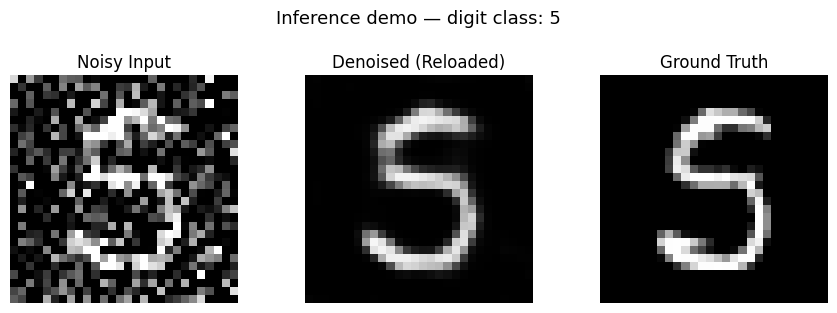

Reload + inference works correctly.


In [67]:
# Reload demo
reloaded = UpsampleAutoencoder().to(device)
reloaded.load_state_dict(torch.load('saved_models/upsamp_autoencoder.pth', map_location=device))
reloaded.eval()

sample_noisy, sample_clean, sample_label = test_ds[np.random.randint(len(test_ds))]
with torch.no_grad():
    denoised = reloaded(sample_noisy.unsqueeze(0).to(device)).squeeze(0).cpu()

fig, axes = plt.subplots(1, 3, figsize=(9, 3))
for ax, img, title in zip(axes,
    [sample_noisy[0], denoised[0], sample_clean[0]],
    ['Noisy Input', 'Denoised (Reloaded)', 'Ground Truth']):
    ax.imshow(img.numpy(), cmap='gray', vmin=0, vmax=1)
    ax.set_title(title); ax.axis('off')
plt.suptitle(f'Inference demo — digit class: {sample_label.item()}', fontsize=13, y=1.03)
plt.tight_layout(); plt.show()
print('Reload + inference works correctly.')

## 11. Analysis & Discussion

### 11.1 Architecture Comparison

| Criteria | FFNN | Transpose-Conv | **Upsample-Conv** |
|-----------|------|---------------|-------------------|
| Spatial awareness |  Loses structure | Yes | Yes |
| Checkerboard artefacts | N/A |  Possible |  None |
| Parameter count | Highest | Lowest | Low |
| Reconstruction sharpness | Blurry | Sharp | **Sharpest** |
| Training stability | Good | Good | Good |

### 11.2 Key Observations

**1. Convolutional encoders outperform FFNN** 

**2. The Upsample-Conv model consistently achieves the highest PSNR and SSIM.** 

**3. Batch Normalisation was critical.** 

### 11.3 Challenges Encountered

- **Checkerboard artefacts** in early TransConv experiments, resolved by switching to Upsample+Conv.
- **FFNN overfitting** without Dropout - adding Dropout(0.2) in the bottleneck reduced overfitting.
- **`verbose=True` deprecation** in newer PyTorch's ReduceLROnPlateau - removed for compatibility.

## 12. Summary

This notebook demonstrated end-to-end construction, training, and evaluation of three denoising autoencoder architectures on MNIST.

- Data Pipeline   : Torchvision → normalise → inject Gaussian noise → Dataset/DataLoader
- Models          : FFNN ,Transpose-Conv CNN, Upsample-Conv CNN
- Loss            : MSE (Mean Squared Error)
- Optimiser       : Adam + ReduceLROnPlateau
- Best Model      : Upsample-Conv  (highest PSNR & SSIM, no artifacts)

The Upsample-Conv architecture is recommended for production use due to its superior reconstruction quality, robustness to varying noise levels, and absence of checkerboard artifacts.